## 实验9 图像多分类任务

### 读取图像数据

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as transforms
import torchvision.models as models

# 设置随机种子和设备
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据集路径
data_dir = "multi-output-classification data"

# 标签映射，特别的，我们有颜色和衣服种类两种分类目标（两个独立的分类头），因此要有两个哈希表
color_map = {"black": 0, "blue": 1, "red": 2}
category_map = {"jeans": 0, "shoes": 1, "dress": 2, "shirt": 3}
color_names = ["black", "blue", "red"]
category_names = ["jeans", "shoes", "dress", "shirt"]

transform_ori = transforms.Compose([
    transforms.Resize((64,64)),  #skimage.transform中的resize默认自带归一化，但是transforms.Resize则不会自带归一化
    transforms.ToTensor(),  # 把读取的图片强转为Tensor，这是因为使用Image读取的图像的数据类型为<class 'PIL.JpegImagePlugin.JpegImageFile'>，而不是张量tensor
                            # 特别的，transforms.ToTensor()不仅会将HWC变成CHW（Pytorch计算需要顺序保持[通道，高度，宽度]），而且会进行归一化！！！
])

transform_train=transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),   #随机水平翻转
    transforms.RandomRotation((-30, 30)),    #小角度随机旋转
    transforms.RandomResizedCrop(  #轻微随机裁剪
        size=(64, 64),  #size是你希望的输出尺寸
        scale=(0.85, 1.0)  #scale是随机裁剪区域面积占原图片面积的比例
                           #通过RandomResizedCrop裁剪出来的初始图像肯定尺寸比size要求小，后期通过拉伸来实现最终尺寸为size
    )
])

class MultiOutputDataset(Dataset):
    """多输出数据集：同时预测颜色和服装类别"""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        for folder in sorted(os.listdir(root_dir)):
            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path):
                continue
            parts = folder.split("_")  #parts是一个python原生的数组，以folder这个字符串被'_'分隔的各部分为元素，这是为了便于我们后面实现多分类任务
            color = parts[0]  #颜色总是在前
            category = parts[1]  #衣服款式总是在后
            color_label = color_map[color]  #获取颜色标签
            category_label = category_map[category]  #获取种类标签
            for fname in os.listdir(folder_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(folder_path, fname), color_label, category_label))  #samples中每个元素都是一个三元组：(图片路径，颜色的哈希标签、种类的哈希标签)
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, color_label, category_label = self.samples[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)
            
        return image, color_label, category_label


MyDataSet=MultiOutputDataset(data_dir,transform=transform_ori)
#打印数据集样本数
print(f"原始数据集样本数：{len(MyDataSet)}")
#打印数据集中图片的大小
print(f"原始数据集中样本图片的形状：{MyDataSet[0][0].shape}")

Using device: cpu
原始数据集样本数：2521
原始数据集中样本图片的形状：torch.Size([3, 64, 64])


### 将数据分为训练集和验证集

In [2]:
#划分训练集/验证集（8:2）
train_size = int(0.8 * len(MyDataSet))
val_size = len(MyDataSet) - train_size
train_dataset, val_dataset = random_split(MyDataSet, [train_size, val_size])

#创建DataLoader
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f'训练集样本数：{len(train_dataset)}')
print(f'验证集样本数：{len(val_dataset)}')

训练集样本数：2016
验证集样本数：505


### 定义网络  
#网络具备2个分类任务  

In [3]:
class MultiTaskModel(nn.Module):
    def __init__(self):
        super().__init__()
        #用ResNet8作为backbone主干
        self.backbone = models.resnet18(weights=None)  #weights=None指的是参数初始化完全随机
        self.backbone.fc = nn.Identity()  #特别的，ResNet8最后一层的全连接层是nn.Linear(512,10)，但是我们的任务并不是10分类的任务，所以要除去这层
        feature_dim = 512

        #此任务为Multi-Task Classification（多任务分类），需要两个独立的分类头head
        self.color_fc = nn.Linear(feature_dim, 3)   # 3种颜色
        self.clothes_fc = nn.Linear(feature_dim, 4) # 4种衣服

    def forward(self, x):
        feat = self.backbone(x)  #我们习惯上将网络提取的全局特征向量的变量名起为feat
        color_out = self.color_fc(feat)
        clothes_out = self.clothes_fc(feat)
        return color_out, clothes_out

### 训练网络

Epoch 1
总损失: 1.341
颜色损失: 1.262 | 颜色准确率: 30.11%
衣服损失: 1.374 | 衣服准确率: 30.56%
------------------------------------------------------------
Epoch 2
总损失: 1.237
颜色损失: 1.096 | 颜色准确率: 36.61%
衣服损失: 1.297 | 衣服准确率: 38.00%
------------------------------------------------------------
Epoch 3
总损失: 1.179
颜色损失: 1.020 | 颜色准确率: 49.55%
衣服损失: 1.247 | 衣服准确率: 44.15%
------------------------------------------------------------
Epoch 4
总损失: 1.154
颜色损失: 0.991 | 颜色准确率: 56.05%
衣服损失: 1.224 | 衣服准确率: 47.17%
------------------------------------------------------------
Epoch 5
总损失: 1.107
颜色损失: 0.959 | 颜色准确率: 60.02%
衣服损失: 1.170 | 衣服准确率: 54.12%
------------------------------------------------------------
Epoch 6
总损失: 1.053
颜色损失: 0.912 | 颜色准确率: 65.23%
衣服损失: 1.113 | 衣服准确率: 61.31%
------------------------------------------------------------
Epoch 7
总损失: 1.034
颜色损失: 0.899 | 颜色准确率: 66.42%
衣服损失: 1.092 | 衣服准确率: 62.25%
------------------------------------------------------------
Epoch 8
总损失: 0.992
颜色损失: 0.875 | 颜色准确率: 67.86%
衣

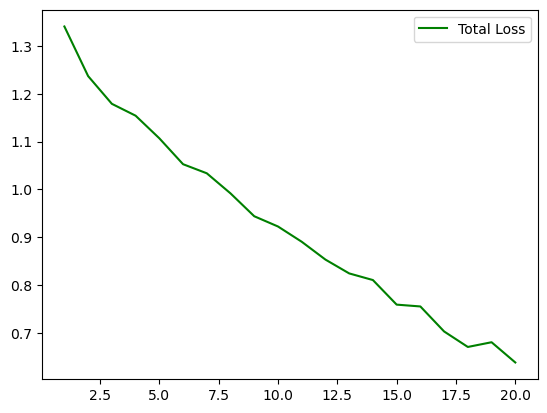

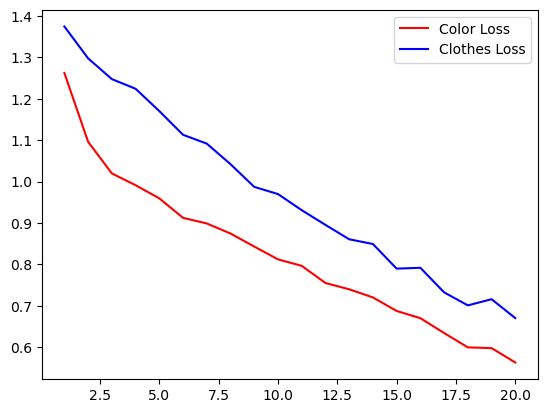

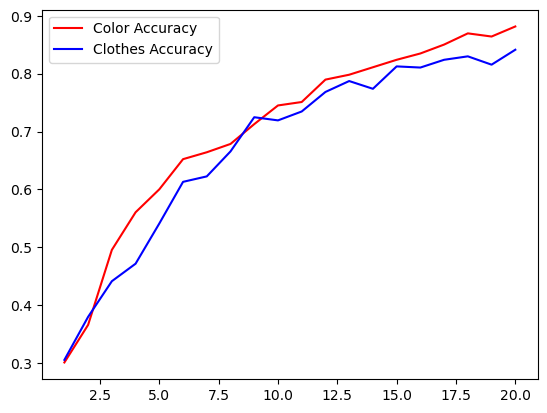

In [4]:
epochs=20

"""
需要说明的是，在这个Multi-task Classifying任务中，区分颜色的难度比起区分衣服类型要简单很多
用人的肉眼就可以说明，也许对于一个模糊或者不够完整的图片，你能直接给出颜色，但未必能准确给出衣服的类型
用CNN识别同理，我们在计算总损失时应该对不同指标进行加权，对于简单的任务，我们让color_loss在total_loss中的占比较小，
对于复杂的任务，让clothes_loss在total_loss中的占比比较大，可以让模型的综合表现能力更好
"""
weight_color=0.3
weight_clothes=0.7

color_losses=[]
clothes_losses=[]
total_losses=[]

color_accuracies=[]
clothes_accuracies=[]

model = MultiTaskModel()

# 两个独立的损失函数
criterion_color = nn.CrossEntropyLoss()
criterion_clothes = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)

for epoch in range(1,epochs+1):
    model.train()
    total_loss = 0.0  #总损失
    color_loss_total = 0.0  #颜色类型损失
    clothes_loss_total = 0.0  #衣服类型损失
    color_acc_total = 0.0  #颜色类型精度
    clothes_acc_total = 0.0  #衣服类型精度

    for imgs, color_labs, clothes_labs in train_loader:
        #如果你想使用cuda加速训练，那么就需要先把会用到的中间变量或相关数据搬到GPU上
        #我的PC只有CPU，删掉.to(device)也可以，这里直接删掉了

        optimizer.zero_grad()  #清空梯度

        # 前向传播
        imgs=transform_train(imgs)  #动态数据增强
        color_out, clothes_out = model(imgs)
        """
        一个值得一提的地方，model明明是抽象类MultiTaskModel的一个实例对象，为什么传入参数imgs还能有返回值？
        这是因为MultiTaskModel继承的父类nn.Module中有一个魔法方法__call__()，它使得nn.Module及其子类的实例对象可以被调用（call在这里就是调用的意思）
        且调用的就是你重写的forward()方法，这就恰好完成了前向传播
        """

        # 两个独立损失
        loss_color = criterion_color(color_out, color_labs)
        loss_clothes = criterion_clothes(clothes_out, clothes_labs)

        # 总损失
        loss = weight_color*loss_color + weight_clothes*loss_clothes

        # 反向传播
        loss.backward()
        #梯度更新
        optimizer.step()

        # 累计，别忘记我们只取标量值而不取整个张量
        total_loss += loss.item()
        color_loss_total += loss_color.item()
        clothes_loss_total += loss_clothes.item()

        # 两个独立准确率
        _,color_predicted=torch.max(color_out,dim=1)
        _,clothes_predicted=torch.max(clothes_out,dim=1)
        color_acc=(color_predicted==color_labs).sum().item()
        clothes_acc=(clothes_predicted==clothes_labs).sum().item()
        color_acc_total += color_acc
        clothes_acc_total += clothes_acc

    total_losses.append(total_loss/len(train_loader))
    color_losses.append(color_loss_total/len(train_loader))
    clothes_losses.append(clothes_loss_total/len(train_loader))

    color_accuracies.append(color_acc_total/len(train_dataset))
    clothes_accuracies.append(clothes_acc_total/len(train_dataset))

    # 打印每一轮结果
    """
    需要注意的是criterion(outputs,labels)计算的已经是这个batch中的平均损失了，因此我们累加所有batch的平均损失后还需要除以len(dataloader)
    但是对于精度，我们将所有预测标签和真实标签相同的匹配对的数量相加后除以的是len(dataset)而不是len(dataloader)
    """
    print(f"Epoch {epoch}")
    print(f"总损失: {total_loss/len(train_loader):.3f}")
    print(f"颜色损失: {color_loss_total/len(train_loader):.3f} | 颜色准确率: {color_acc_total/len(train_dataset):.2%}")
    print(f"衣服损失: {clothes_loss_total/len(train_loader):.3f} | 衣服准确率: {clothes_acc_total/len(train_dataset):.2%}")
    print("-" * 60)

plt.figure()
plt.plot(np.arange(1,epochs+1),total_losses,color='green',label='Total Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1),color_losses,color='red',label='Color Loss')
plt.plot(np.arange(1,epochs+1),clothes_losses,color='blue',label='Clothes Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1),color_accuracies,color='red',label='Color Accuracy')
plt.plot(np.arange(1,epochs+1),clothes_accuracies,color='blue',label='Clothes Accuracy')
plt.legend()
plt.show()

**可以看到震荡比较严重，这可能是由于数据增强的强度过高或者是学习率过大导致的**  
**通过增加epoch数，模型最终的预测精度还能进一步提升**
**通过对损失进行加权，我们发现两项不同的分类指标的损失相差不大，这有利于防止过拟合，因为这两个维度在更新时用的是同一个学习率，问题简单的那一个往往容易过拟合，使用加权损失后，反向传播时梯度计算图也会将这个权重一步步传下去，这样简单问题的参数更新慢，不容易过拟合**

#### 在验证集上验证

In [6]:
import warnings
warnings.filterwarnings("ignore")  #用来屏蔽警告

model.eval()  #切换至验证模式

criterion_color=nn.CrossEntropyLoss()
criterion_clothes=nn.CrossEntropyLoss()

total_loss=0.0
color_total_loss=0.0
clothes_total_loss=0.0

color_total_accuracy=0.0
clothes_total_accuracy=0.0

"""
Pytorch中，每次前向传播都会记录传播图，以便反向传播和更新参数，但是此时在验证集上用不到，我们执行torch.no_grad()即可关闭
至于with关键字，用于实现上下文管理器，我们进入下述代码块时执行torch.no_grad()，退出这个代码块torch.no_grad()失效，恢复正常
"""
with torch.no_grad():
    for imgs,color_labels,clothes_labels in val_loader:
        color_out,clothes_out=model(imgs)

        color_loss=criterion_color(color_out,color_labels)
        clothes_loss=criterion_clothes(clothes_out,clothes_labels)

        _,color_predicted=torch.max(color_out,dim=1)
        _,clothes_predicted=torch.max(clothes_out,dim=1)

        color_accuracy=(color_predicted==color_labels).sum().item()
        clothes_accuracy=(clothes_predicted==clothes_labels).sum().item()

        color_total_loss+=color_loss.item()
        clothes_total_loss+=clothes_loss.item()

        color_total_accuracy+=color_accuracy
        clothes_total_accuracy+=clothes_accuracy

total_loss=weight_color*color_total_loss+weight_clothes*clothes_total_loss

print(f'总损失为：{total_loss/len(val_loader):.3f}')
print(f'颜色损失为：{color_total_loss/len(val_loader):.3f}，衣服损失为：{clothes_total_loss/len(val_loader):.3f}')
print(f'颜色准确率为：{color_total_accuracy/len(val_dataset):.2%}，衣服准确率为：{clothes_total_accuracy/len(val_dataset):.2%}')

总损失为：0.578
颜色损失为：0.526，衣服损失为：0.600
颜色准确率为：88.12%，衣服准确率为：85.54%


**可以看到模型在验证集上的表现和最终在训练集上的表现一致，这说明模型并没有发生过拟合**

### 实验结果与分析
#e.g.哪些策略提升了分类精度  

**1. 动态的数据增强，包括随机水平翻转、随机小幅度旋转和随机裁剪**  
**2. 迁移学习，使用了resnet18**  
**3. 对总损失进行加权处理，让简单问题的损失权重较低，让复杂问题的损失权重较高**

### 总结

**1. 对于类似本任务的Multi-Task Classifying，我们可以对不同指标的损失进行加权，以便于让模型更好的学习**  
**2. 对于数据增强中的随机垂直翻转要慎用，如果垂直翻转会破坏图片的原有语义则不得使用，本问题中不可以使用，因为衣服的上下部分有关系**

### 评分标准：
#测试精度越高，得分越高  
#只能提交PDF  
#代码尽量简洁高效，不包含实验题目无关的函数、代码  
#按照题目大纲编写程序  
#课上能够完成加分   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   
##### 